<a href="https://colab.research.google.com/github/arshiafreen090/ML-Supervised-Classification/blob/main/Heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [5]:
df= pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.shape

(918, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


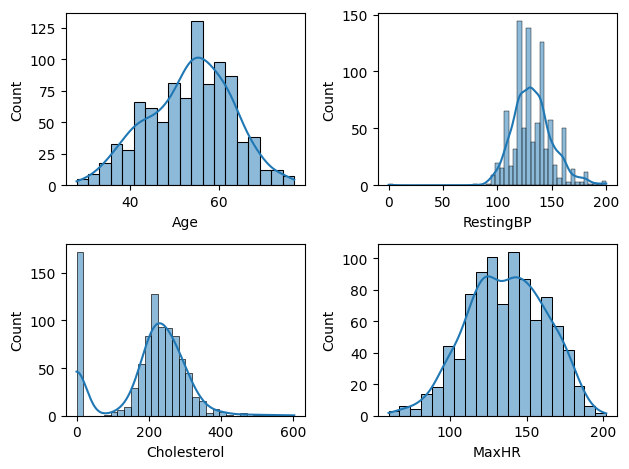

In [11]:
# plots
def plotting (var, num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [12]:
# chlestrol, restingBP kinda looks sus, cuz chlestrol and restingBP cant be that 0.
# so let's replace it with mean of the col.
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'].replace(0,ch_mean,inplace=True)
df['Cholesterol'] = df['Cholesterol'].round(2)
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


In [13]:
RestingBP_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'].replace(0,RestingBP_mean,inplace=True)
df['RestingBP'] = df['RestingBP'].round(2)
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [14]:
display(df['ChestPainType'].value_counts())
display(df['ST_Slope'].value_counts())

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


,count
ST_Slope,
Flat,460
Up,395
Down,63


In [15]:
display(df['RestingBP'].value_counts())
display(df['Cholesterol'].value_counts())

,count
RestingBP,
120.0,132
130.0,118
140.0,107
110.0,58
150.0,55
...,...
101.0,1
117.0,1
192.0,1


,count
Cholesterol,
244.64,172
254.00,11
220.00,10
223.00,10
204.00,9
...,...
353.00,1
278.00,1
157.00,1


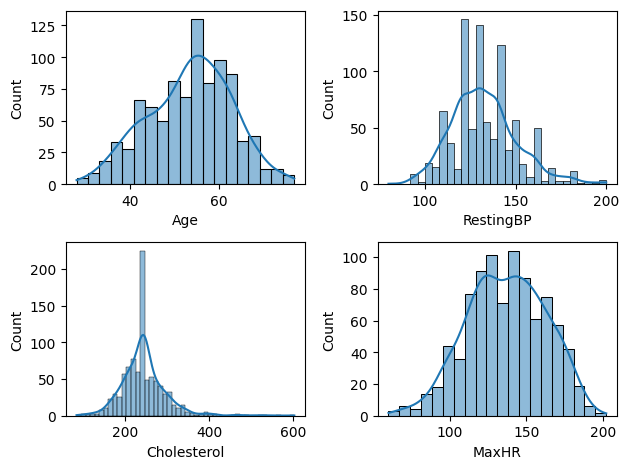

In [16]:
# plots
def plotting (var, num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

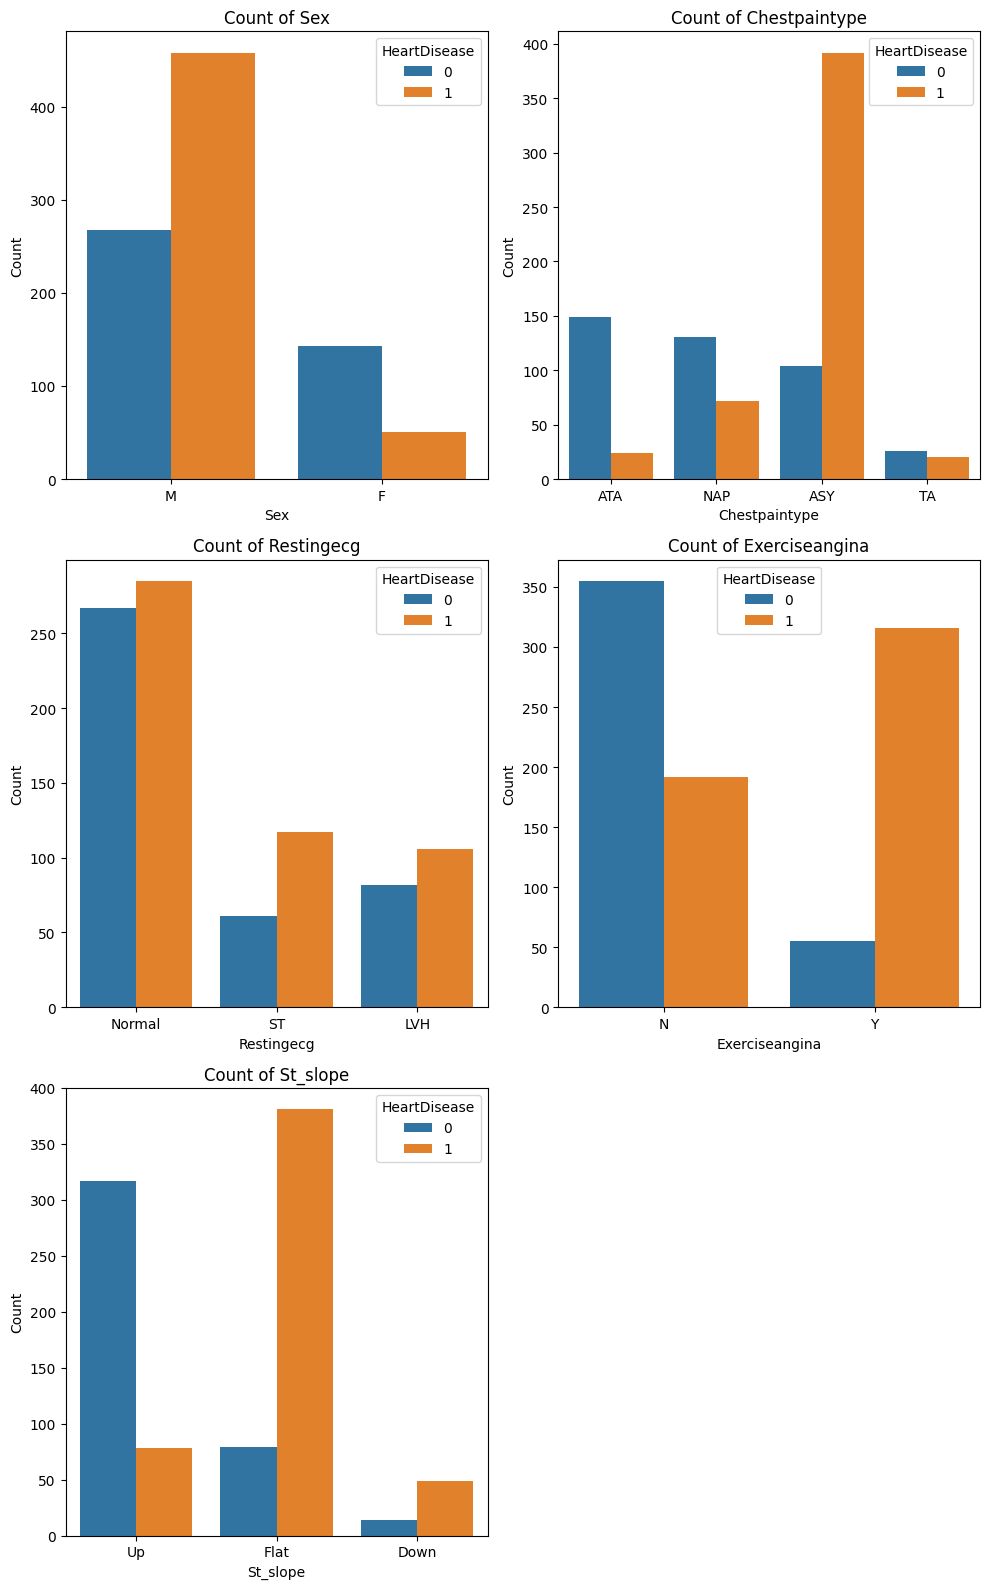

In [17]:
cat_cols=['Sex','ChestPainType', 'RestingECG','ExerciseAngina','ST_Slope']
n_cols=2
n_rows= (len(cat_cols)+ n_cols-1)// n_cols #celling func
fig,axes= plt.subplots(nrows=n_rows, ncols=n_cols,figsize=(10, 16))
axes= axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(x= df[col],hue=df['HeartDisease'] , ax=axes[i])
    axes[i].set_title(f'Count of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')

# Turn off any unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

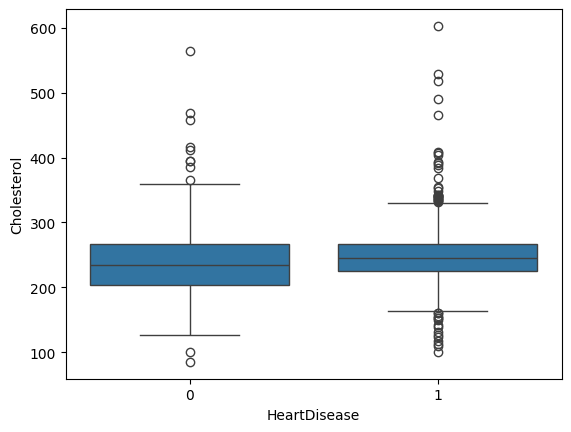

In [18]:

sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

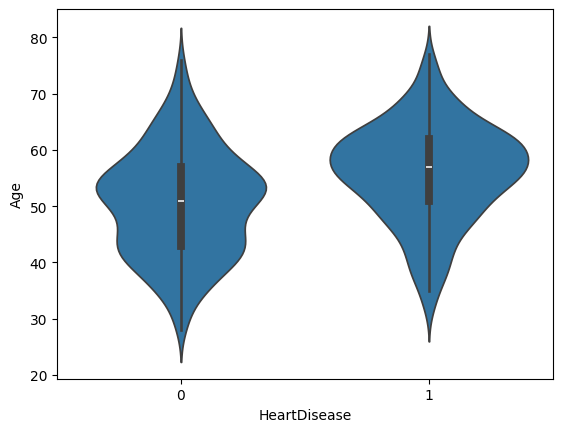

In [19]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

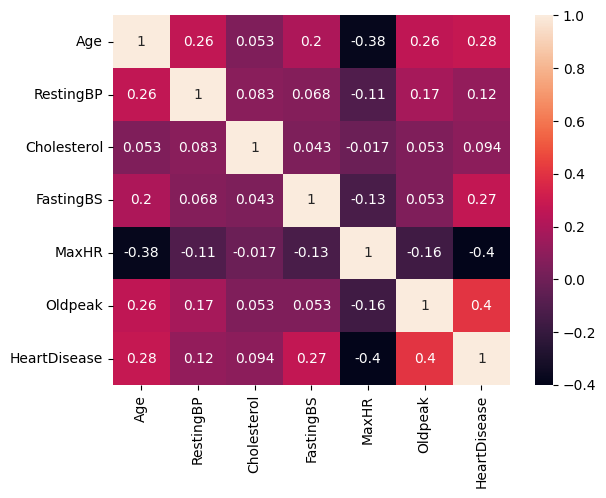

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data perprocessing and cleaning

In [21]:
df_cleaned = df.copy()
df_cleaned

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [22]:
num_features = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'Oldpeak'
]

cat_features = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

In [23]:
df_cleaned.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [24]:
df_cleaned.duplicated().sum()

np.int64(0)

In [25]:
for col in cat_features:
    print(f"\n")
    print(df_cleaned[col].value_counts())



Sex
M    725
F    193
Name: count, dtype: int64


ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [26]:
from scipy.stats import chi2_contingency

alpha = 0.05

chi2_results = {}

for col in cat_features:

    contingency = pd.crosstab(
        df_cleaned[col],
        df_cleaned['HeartDisease']
    )

    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values('p_value')

chi2_df

,chi2_statistic,p_value
ST_Slope,355.918443,5.167638e-78
ChestPainType,268.067239,8.083728e-58
ExerciseAngina,222.259383,2.907808e-50
Sex,84.145101,4.597617e-20
RestingECG,10.931469,4.229233e-03


In [27]:
from scipy.stats import ttest_ind

ttest_results = {}

for col in num_features:

    group_0 = df_cleaned[df_cleaned['HeartDisease'] == 0][col]
    group_1 = df_cleaned[df_cleaned['HeartDisease'] == 1][col]

    t_stat, p_val = ttest_ind(
        group_0,
        group_1,
        equal_var=False
    )

    ttest_results[col] = {
        't_statistic': t_stat,
        'p_value': p_val
    }

ttest_df = pd.DataFrame(ttest_results).T
ttest_df = ttest_df.sort_values('p_value')

ttest_df

,t_statistic,p_value
Oldpeak,-14.040031,1.902722e-40
MaxHR,13.231478,1.430637e-36
Age,-8.822540,6.348337e-18
FastingBS,-8.760286,9.852286e-18
RestingBP,-3.646985,2.803911e-04
Cholesterol,-2.850447,4.469761e-03


In [28]:
for col in num_features:
    print(f"\n{col}")
    print(df_cleaned.groupby('HeartDisease')[col].mean())


Age
HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

RestingBP
HeartDisease
0    130.180488
1    134.445945
Name: RestingBP, dtype: float64

Cholesterol
HeartDisease
0    239.055610
1    249.140315
Name: Cholesterol, dtype: float64

FastingBS
HeartDisease
0    0.107317
1    0.334646
Name: FastingBS, dtype: float64

MaxHR
HeartDisease
0    148.151220
1    127.655512
Name: MaxHR, dtype: float64

Oldpeak
HeartDisease
0    0.408049
1    1.274213
Name: Oldpeak, dtype: float64


In [29]:
mean_comparison = df_cleaned.groupby('HeartDisease')[num_features].mean().T

mean_comparison['Difference'] = (
    mean_comparison[1] - mean_comparison[0]
)

mean_comparison

HeartDisease,0,1,Difference
Age,50.551220,55.899606,5.348387
RestingBP,130.180488,134.445945,4.265457
Cholesterol,239.055610,249.140315,10.084705
FastingBS,0.107317,0.334646,0.227329
MaxHR,148.151220,127.655512,-20.495708
Oldpeak,0.408049,1.274213,0.866164


In [30]:
df_cleaned[num_features + ['HeartDisease']].corr()['HeartDisease'].sort_values(
    ascending=False
)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.117938
Cholesterol,0.094082
MaxHR,-0.400421


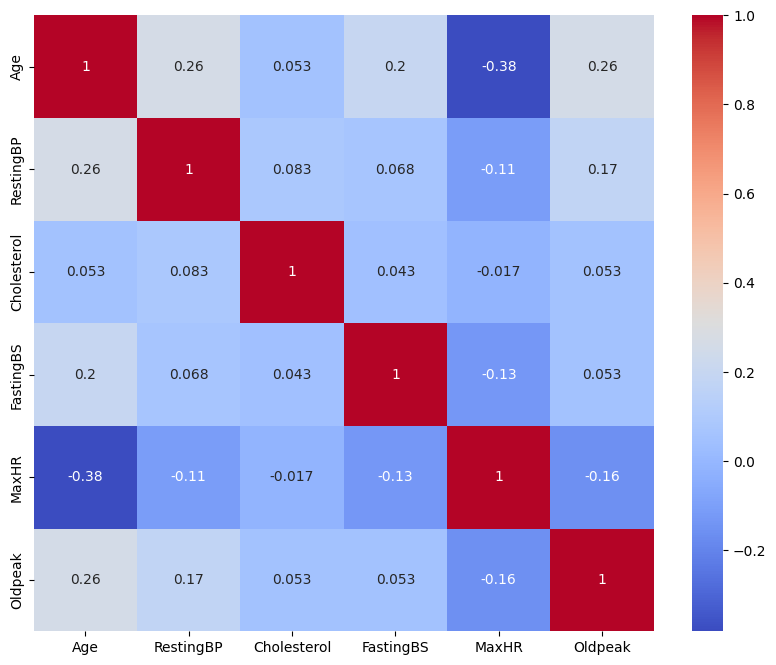

In [31]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_cleaned[num_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [32]:
df_cleaned.groupby('ChestPainType')['HeartDisease'].mean().sort_values()

,HeartDisease
ChestPainType,
ATA,0.138728
NAP,0.354680
TA,0.434783
ASY,0.790323


In [33]:
df_cleaned.groupby('ST_Slope')['HeartDisease'].mean().sort_values()

,HeartDisease
ST_Slope,
Up,0.197468
Down,0.777778
Flat,0.828261


In [34]:
# At this stage, I would not remove any of your original features.

In [35]:
df_cleaned = pd.get_dummies(df,drop_first=True)

In [36]:
df_cleaned

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [37]:
bool_cols = df_cleaned.select_dtypes('bool').columns

df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)

In [38]:
df_cleaned

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [39]:
display(df_cleaned.info())
display(df_cleaned.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    int64  
 8   ChestPainType_ATA  918 non-null    int64  
 9   ChestPainType_NAP  918 non-null    int64  
 10  ChestPainType_TA   918 non-null    int64  
 11  RestingECG_Normal  918 non-null    int64  
 12  RestingECG_ST      918 non-null    int64  
 13  ExerciseAngina_Y   918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(3), int64(13)
m

None

,0
Age,0
RestingBP,0
Cholesterol,0
FastingBS,0
MaxHR,0
Oldpeak,0
HeartDisease,0
Sex_M,0
ChestPainType_ATA,0
ChestPainType_NAP,0


## Model Training

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [41]:
# Train-test split
'''
X_train → 80% → model learns from this
X_test  → 20% → model is tested on this
'''

'\nX_train → 80% → model learns from this\nX_test  → 20% → model is tested on this\n'

In [42]:
X = df_cleaned.drop('HeartDisease', axis=1)
y = df_cleaned['HeartDisease']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [44]:
# StandardScaler
scaler = StandardScaler()

In [45]:
# fit only on training data:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

In [47]:
results = []

In [65]:
from sklearn.metrics import accuracy_score, f1_score,recall_score,precision_score

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred)
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,F1 Score,Recall,Precision
0,Logistic Regression,0.8913,0.9029,0.911765,0.894231
1,Decision Tree,0.7283,0.7549,0.754902,0.754902
2,Support Vector Machine,0.8587,0.8750,0.892157,0.858491
3,K-Nearest Neighbors,0.8913,0.9029,0.911765,0.894231
4,Naive Bayes,0.8750,0.8844,0.862745,0.907216


In [68]:

import joblib
joblib.dump(models['K-Nearest Neighbors'],'knn_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']